# What is Persistence

- Persistence is `LangGraph` refers to the ability to save and restore the state of a workflow over time

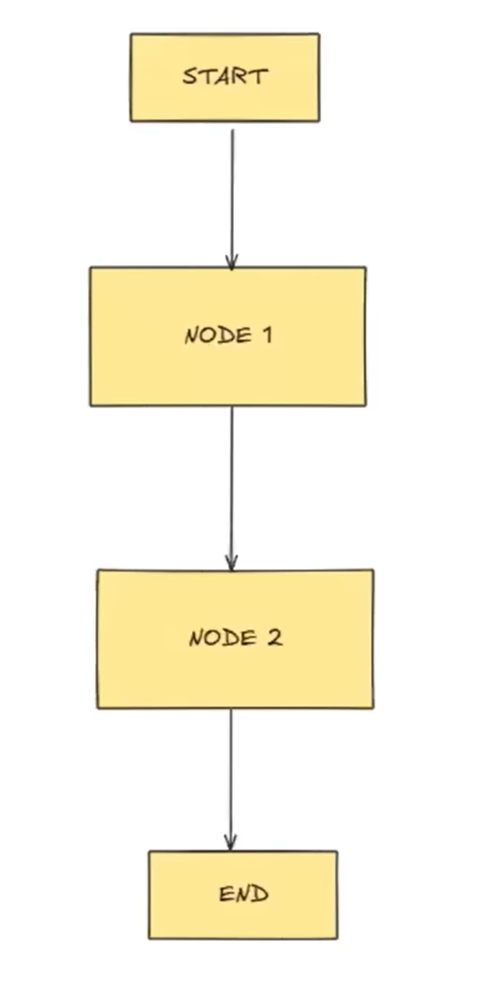


Normally, when we use an LLM:

* You send a message
* It replies
* Conversation is not saved automatically

If program crashes → everything is lost ❌

LangGraph solves this using **Persistence**.

Persistence means:

> Saving the graph’s state after every step.

This helps in:

* Building chatbots
* Saving memory
* Resuming after crash
* Time travel (going back to previous step)

---

## What is Persistence?

Persistence =
👉 Saving everything that happened in the graph.

It saves:

* Messages
* Tool outputs
* Current state
* Execution step
* Metadata

### 🔹 Simple Example

Without persistence:

```text
User: What is 2+2?
Bot: 4
(Program crashes)
→ Conversation lost ❌
```

With persistence:

```text
User: What is 2+2?
Bot: 4
(Program crashes)
→ Restart program
→ Resume from last state ✅
```

---

## Speciality of Persistence

LangGraph persistence is powerful because:

1. It saves full conversation history
2. It saves execution progress
3. It supports multiple users
4. It allows time travel
5. It allows pausing and resuming

It is NOT just chat history.
It saves **entire workflow state**.

---

## Building Chatbots

Persistence is very important for chatbots.

Why?

Because chatbot needs:

* Memory of previous messages
* Context awareness
* Multi-step reasoning

### 🔹 Example

User: My name is Mohit
Bot: Nice to meet you Mohit

Later:

User: What is my name?

With persistence → Bot remembers: Mohit ✅
Without persistence → Bot forgets ❌

---

## Checkpointer

Checkpointer is the tool that saves the state.

Think of it like:

> Auto-save feature in MS Word.

Every time something changes → it saves automatically.

In LangGraph:

```python
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

app = workflow.compile(checkpointer=checkpointer)
```

Now state will be saved after every step.

---

## Example of Checkpointer

When invoking:

```python
app.invoke(
    {"messages": [...]},
    config={"configurable": {"thread_id": "1"}}
)
```

Important thing:
👉 thread_id

This tells LangGraph:
“Which conversation is this?”

---

## Threads

Thread = Conversation ID

Think like WhatsApp chats.

You have:

* Chat with Friend A
* Chat with Friend B

Both are separate.

Same in LangGraph:

| User  | Thread ID |
| ----- | --------- |
| Mohit | 1         |
| Rahul | 2         |

Each thread:

* Has separate memory
* Has separate state

If Mohit sends message:
It won’t mix with Rahul’s conversation.

---

## Implementation (Simple Flow)

Steps:

1. Create state schema
2. Create nodes
3. Connect nodes
4. Add checkpointer
5. Use thread_id while calling

Simple structure:

```python
workflow = StateGraph(StateSchema)

workflow.add_node("chatbot", chatbot_function)
workflow.set_entry_point("chatbot")

app = workflow.compile(checkpointer=MemorySaver())

app.invoke(
    {"messages": [...]},
    config={"configurable": {"thread_id": "mohit"}}
)
```

Now:

* State auto-saves
* Conversation continues
* Resume possible

---

## Benefits of Persistence

Why do we need it?

1. Resume after crash
2. Memory support
3. Multi-user support
4. Debugging easy
5. Supports time travel
6. Human approval flow

It makes agents production-ready.

---

## Short Term Memory

Short-term memory = Current conversation memory.

It includes:

* Chat messages
* Tool results
* Intermediate data

Example:

User: What is 5 * 10?
Bot calls calculator tool → gets 50
That result is stored in state.

---

## Fault Tolerance

Imagine:

Agent is doing 10-step task.

Step 6 → Program crashes.

Without persistence:
→ Start again from step 1 ❌

With persistence:
→ Resume from step 6 ✅

Very useful for:

* Long workflows
* Research agents
* Finance systems

---

## Human in Loop

Sometimes AI should ask human before continuing.

Example:

Agent wants to send email.

Flow:

1. AI writes email
2. Ask human: Approve?
3. Human edits
4. Continue execution

Persistence allows:
Pause → Wait → Resume

Without persistence:
Cannot safely pause.

---

## Time Travel

Time Travel = Going back to previous step.

Imagine:

Step 1: User asks question
Step 2: Agent calls tool
Step 3: Tool gives wrong result

You can:

→ Go back to Step 1
→ Modify state
→ Run again

This is called Time Travel.

It is possible because:
Every step is saved.

Very powerful for:

* Debugging agents
* Improving logic
* Testing different paths

---

## Final Summary

Persistence in LangGraph means:

✅ Save everything  
✅ Resume anytime  
✅ Support multi-user  
✅ Memory handling  
✅ Crash recovery  
✅ Time travel  

Without persistence:
LangGraph = Normal LLM

With persistence:
LangGraph = Powerful AI Agent System 🚀
